# Generate FLUKA input files for T2R and leNuSTORM ring simulation

Generate the FLUKA files for the Pion Transfer line and LEnuSTORM Ring

Uses:
- essbeamsim.py 
- essbeamsim_plots.py
- essbeamsim.yaml

Needs:
Xsuite installation from : https://xsuite.readthedocs.io/en/latest/

Status: 
12.11.2025 : code completed up to the generation of the beam (TR2 and NUSTORM) elements.
        
To do:
- generate the global volumes of the tunnels etc. 

In [201]:
import numpy as np
import pandas as pd

import xobjects as xo
import xtrack as xt

import math

import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import re
import json
import yaml, pprint
# from dotdict import DotDict as dd


import essbeamsim as bsim
import essbeamsim_plots as bplot

import scipy
import scipy.constants

from particle import Particle

print(f' Beam parameters : ')
import os

%run ../InitPlots.py
    
MyPlots().configPlots('')

print_array_with_format = lambda x : ' '.join(f'{v:.5f}' for v in x)
distance2d = lambda x,y : np.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)


 Beam parameters : 

>>> Running InitPlots.py - Version : 1.02 - 07.03.2023 (IE)
---- running configPlots function 


In [202]:
with open('essbeamsim.yaml','r') as fin:
    config = bsim.DotDict(yaml.safe_load(fin))
pprint.pprint(config)

{'beam_size': 0.1,
 'd1_aperture_margin': 1.2,
 'h_decay_tunnel': 13,
 'h_ring_tunnel': 4,
 'h_tline_tunnel': 4,
 'l_decay_tunnel': 60,
 'magnet_width': 0.8,
 'mparking_radius': 10,
 'mparking_start': [0, 0, -101],
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'r_decay_pipe': 2.5,
 'ring_walls': 2,
 'ss_to_lemmond': 50,
 't2r': {'l_bend_end': 0.35,
         'l_bend_woke': 0.5,
         'l_qfl_end': 0.2,
         'l_qfl_h': 0.9,
         'l_qfl_w': 0.9,
         'l_quad_end': 0.2,
         'l_quad_h': 0.6,
         'l_quad_w': 0.6,
         'l_vac': 0.1},
 't2r_start': [0, 2.0],
 't2rend_to_inj': [-2, 6.0],
 't2rstart_to_inj': [-9.08278251237319, 23.1539181004073],
 't_tline_tunnel': 2,
 'trg_to_lblnd': 320,
 'w_decay_tunnel': 14,
 'w_ring_tunnel': 2,
 'w_tline_tunnel': 5}


## Reminder on Beam Parameters

Reminder on beam energy and momentum

$E = E_{kin} + E_0(=\mathrm{m}_0\, c^2)$

$E^2 = E_0^2 + P^2 \Rightarrow P^2 = \sqrt{E^2 - E_0^2} \Rightarrow P = \sqrt{(E-E_0)(E+E_0)}$

$P = \sqrt{E_{kin}(E_{kin}+2E_0)}$

$\beta\gamma = P/\mathrm{m}_0$

$\gamma = \sqrt{(\beta\gamma)^2+1}$

$\beta = \beta\gamma/\gamma$

In [203]:
pion = Particle.from_name('pi+')
muon = Particle.from_name('mu+')
proton = Particle.from_name('p')

# particle mass [MeV/c2] --> convert to [GeV/c2]
pmass_gev = proton.mass/1000
pimass_gev = pion.mass/1000
mumass_gev = muon.mass/1000

# print(xx.mass, xx.lifetime*1.0e-9)

# primary proton beam
pbeam_ekk_gev = 2.5
pbeam_etot = pbeam_ekk_gev + pmass_gev
pbeam_mom_gev = np.sqrt(pbeam_ekk_gev*(pbeam_ekk_gev+2*pmass_gev))
pbeam_beta, pbeam_gamma = bsim.particle_beta_gamma('p', pbeam_mom_gev)

# pion beam
beam_momentum = 0.7
pion_beta, pion_gamma = bsim.particle_beta_gamma('pi+', beam_momentum)
pion_decay_length = pion.lifetime*1.0e-9*scipy.constants.c*pion_gamma

# muon beam
muon_momentum = 0.4
muon_beta, muon_gamma = bsim.particle_beta_gamma('mu+', muon_momentum)
muon_lifetime = muon.lifetime*1.0e-9*muon_gamma  # lifetime is given in ns
muon_decay_length = muon_lifetime*scipy.constants.c

muon_momentum_max = 0.7
muon_beta_max, muon_gamma_max = bsim.particle_beta_gamma('mu+', muon_momentum_max)
muon_lifetime_max = muon.lifetime*1.0e-9*muon_gamma_max  # lifetime is given in ns
muon_decay_length_max = muon_lifetime_max*scipy.constants.c

print(f''' Paramters (units in GeV)
            primary proton beam:
                {pbeam_ekk_gev=}
                {pbeam_etot=:.5f}
                {pbeam_mom_gev=:.5f}
                {pbeam_gamma=:.5f}
                {pbeam_beta=:.5f}
            extracted pion beam:
                {beam_momentum=}
                {pion_gamma=:.5f} [s]
                {pion_decay_length=:.5f} [m]
            stored muon beam:
                {muon_momentum=}
                {muon_beta=:.5f}
                {muon_gamma=:.5f}
                {muon_lifetime=:.5f} [s], {muon_lifetime/1.0e-6:.5f} [us]
                {muon_decay_length=:.5f} [m]
                
                {muon_momentum_max=}
                {muon_beta_max=:.5f}
                {muon_gamma_max=:.5f}
                {muon_lifetime_max=:.5f} [s], {muon_lifetime_max/1.0e-6:.5f} [us]
                {muon_decay_length_max=:.5f} [m]
        ''')

 Paramters (units in GeV)
            primary proton beam:
                pbeam_ekk_gev=2.5
                pbeam_etot=3.43827
                pbeam_mom_gev=3.30777
                pbeam_gamma=3.66447
                pbeam_beta=0.96205
            extracted pion beam:
                beam_momentum=0.7
                pion_gamma=5.11411 [s]
                pion_decay_length=39.91268 [m]
            stored muon beam:
                muon_momentum=0.4
                muon_beta=0.96684
                muon_gamma=3.91563
                muon_lifetime=0.00001 [s], 8.60257 [us]
                muon_decay_length=2578.98569 [m]
                
                muon_momentum_max=0.7
                muon_beta_max=0.98880
                muon_gamma_max=6.70017
                muon_lifetime_max=0.00001 [s], 14.72015 [us]
                muon_decay_length_max=4412.98966 [m]
        


## Load the LEnuSTORM lattice

In [204]:

def get_kvalue(r):
    if r.element_type == 'Bend':
        return r.element.k0
    elif r.element_type == 'Quadrupole' :
        return r.element.k1
    else:
        return 0
    
def get_flukadf(df, verbose=False):
    ''' Prepare the beam elements DF for FLUKA'''

    df['length'] = df['s_end'] - df['s_start']
    df['kvalue'] = df.apply(lambda x: get_kvalue(x), axis=1)

    mask = ((df.element_type != 'Drift') & (df.kvalue != 0)) | (df.element_type == 'Marker')

    df = df[mask].copy()
    
    df['length_cm'] = df['length'].apply(lambda x: x*100)
    df['X_cm']      = df['X'].apply(lambda x: x*100)
    df['Y_cm']      = df['Y'].apply(lambda x: x*100)
    df['Z_cm']      = df['Z'].apply(lambda x: x*100)
    df['theta_deg'] = df['theta'].apply(lambda x: x*180/np.pi)
    
    df['belement'] = df["name"].str[:2] + (df.groupby(df["name"].str[:2]).cumcount() + 1).astype(str)
    df['model'] = np.select(
        [
            df['element_type'] == 'Bend',
            df['element_type'] == 'Quadrupole'
        ],
        [
            'MB' + (df['length'] * 100).round().astype(int).astype(str),
            'QM' + (df['length'] * 100).round().astype(int).astype(str)
        ],
        default= np.nan
        )
    if verbose:
        mask = df.element_type.isin(['Bend', 'Quadrupole'])
        print(f' -- belements: {set(df["belement"][mask].unique())}')
        print(f' -- models: {set(df["model"][mask].unique())}')

    return df

In [205]:
# fin = '../src/ring-mb3.json'
fin = '../src/one-alternating-bend_ring600.json'
nustormring = xt.Line.from_json(fin)

add_inj_marker = False
if add_inj_marker : 
    env = nustormring.env
    env.new('t2rinj', xt.Marker)

    # --- add injection marker
    nustormring.insert([
        env.place('t2rinj', at=100.325)
    ])

    # --- cycle the ring to start from a given element
    nustormring.cycle(name_first_element='t2rinj', inplace=True)

nustormring_df = nustormring.to_pandas()

ringsrv_df = nustormring.survey().to_pandas()
ringsrv_df = ringsrv_df.rename(columns={'name':'name_srv'})
display(ringsrv_df.head(20))

nustormring_df = nustormring_df.join(ringsrv_df[['name_srv','X','Y','Z','theta','phi','psi','angle','tilt']], how='outer')
assert nustormring_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

nustormring_elements_df = get_flukadf(nustormring_df, verbose=True)
display(nustormring_elements_df.head(20))

Loading line from dict:   0%|          | 0/52 [00:00<?, ?it/s]

Done loading line from dict.           


,X,Y,Z,theta,phi,psi,name_srv,s,length,isthick,drift_length,angle,tilt,element_type
0,0.0,0.0,0.000,0.0,0.0,0.0,RING_ORIGIN,0.000,0.000,False,0.000,0.0,0.0,Marker
1,0.0,0.0,0.000,0.0,0.0,0.0,QF.A::0,0.000,0.125,True,0.125,0.0,0.0,Quadrupole
2,0.0,0.0,0.125,0.0,0.0,0.0,D.S2A::0,0.125,1.300,True,1.300,0.0,0.0,Drift
3,0.0,0.0,1.425,0.0,0.0,0.0,QD.M2::0,1.425,0.250,True,0.250,0.0,0.0,Quadrupole
4,0.0,0.0,1.675,0.0,0.0,0.0,D.S2A::1,1.675,1.300,True,1.300,0.0,0.0,Drift
5,0.0,0.0,2.975,0.0,0.0,0.0,QF.M1::0,2.975,0.250,True,0.250,0.0,0.0,Quadrupole
6,0.0,0.0,3.225,0.0,0.0,0.0,D.S2A::2,3.225,1.300,True,1.300,0.0,0.0,Drift
7,0.0,0.0,4.525,0.0,0.0,0.0,QD.M1::0,4.525,0.250,True,0.250,0.0,0.0,Quadrupole
8,0.0,0.0,4.775,0.0,0.0,0.0,D.S2A::3,4.775,1.300,True,1.300,0.0,0.0,Drift
9,0.0,0.0,6.075,0.0,0.0,0.0,QF.M0::0,6.075,0.250,True,0.250,0.0,0.0,Quadrupole


 -- belements: {'QD82', 'QF29', 'QD111', 'QF12', 'B.10', 'QF100', 'QD57', 'QD68', 'QF91', 'QD37', 'QD90', 'QD112', 'QF20', 'QD132', 'QF121', 'QF122', 'QD63', 'QF58', 'QD64', 'B.16', 'QF51', 'QD83', 'QF98', 'QD73', 'QF84', 'B.5', 'QF60', 'QD105', 'QD135', 'QD117', 'QF53', 'QD35', 'QD128', 'QF97', 'QF92', 'QD32', 'QF39', 'QF133', 'QD42', 'QF88', 'QD49', 'QF27', 'QF57', 'QD41', 'QD69', 'QD53', 'QF103', 'QF44', 'QF54', 'QF127', 'QF61', 'B.15', 'B.14', 'QD134', 'QF89', 'QD89', 'QF48', 'QD39', 'QD58', 'QF42', 'QD98', 'QF99', 'QD5', 'QD40', 'QF69', 'QF126', 'QD20', 'QD103', 'QF28', 'QD129', 'QD67', 'QF41', 'QF76', 'QD114', 'B.19', 'QF128', 'QD138', 'QF120', 'QF110', 'QD133', 'QD100', 'QF9', 'QD13', 'QF43', 'QD50', 'QF75', 'QD19', 'QF137', 'QD43', 'QF143', 'QD51', 'QF70', 'QD109', 'QD26', 'QD97', 'QD124', 'QD29', 'QD95', 'QF71', 'QF22', 'B.20', 'QF112', 'QD80', 'QD99', 'QF114', 'QF87', 'QF68', 'QF35', 'QD92', 'QF74', 'QD126', 'QD54', 'QF72', 'QD106', 'QF67', 'QD123', 'QF36', 'QF21', 'QD27', 'Q

,s,element_type,name,isthick,isreplica,parent_name,iscollective,element,s_start,s_center,...,tilt,length,kvalue,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.000,Marker,RING_ORIGIN,False,False,None,False,Marker(),0.000,0.0000,...,0.0,0.000,0.000000,0.0,0.0,0.0,0.0,0.0,RI1,NaN
1,0.000,Quadrupole,QF.A,True,False,None,False,"Quadrupole(k1=2.19, k1s=0, length=0.125, num_m...",0.000,0.0625,...,0.0,0.125,2.194177,12.5,0.0,0.0,0.0,0.0,QF1,QM12
3,1.425,Quadrupole,QD.M2,True,False,None,False,"Quadrupole(k1=-2.09, k1s=0, length=0.25, num_m...",1.425,1.5500,...,0.0,0.250,-2.089355,25.0,0.0,0.0,142.5,0.0,QD1,QM25
5,2.975,Quadrupole,QF.M1,True,False,None,False,"Quadrupole(k1=2.31, k1s=0, length=0.25, num_mu...",2.975,3.1000,...,0.0,0.250,2.307367,25.0,0.0,0.0,297.5,0.0,QF2,QM25
7,4.525,Quadrupole,QD.M1,True,False,None,False,"Quadrupole(k1=-2.42, k1s=0, length=0.25, num_m...",4.525,4.6500,...,0.0,0.250,-2.419313,25.0,0.0,0.0,452.5,0.0,QD2,QM25
9,6.075,Quadrupole,QF.M0,True,False,None,False,"Quadrupole(k1=2.92, k1s=0, length=0.25, num_mu...",6.075,6.2000,...,0.0,0.250,2.916284,25.0,0.0,0.0,607.5,0.0,QF3,QM25
11,7.625,Quadrupole,QD.M0,True,False,None,False,"Quadrupole(k1=-2.97, k1s=0, length=0.25, num_m...",7.625,7.7500,...,0.0,0.250,-2.971037,25.0,0.0,0.0,762.5,0.0,QD3,QM25
13,9.175,Quadrupole,QF.S,True,False,None,False,"Quadrupole(k1=3.31, k1s=0, length=0.125, num_m...",9.175,9.2375,...,0.0,0.125,3.311778,12.5,0.0,0.0,917.5,0.0,QF4,QM12
14,9.300,Marker,matching_start,False,False,None,False,Marker(),9.300,9.3000,...,0.0,0.000,0.000000,0.0,0.0,0.0,930.0,0.0,ma1,NaN
15,9.300,Marker,start_cell.S.ShFoDo0,False,False,None,False,Marker(),9.300,9.3000,...,0.0,0.000,0.000000,0.0,0.0,0.0,930.0,0.0,st1,NaN


In [206]:
if 0 : 
    _nustormtbl = nustormring.get_table()
    print(_nustormtbl.cols)
    # _nustormtbl.show()
    _nustormtbl.rows[_nustormtbl.element_type=='Bend']


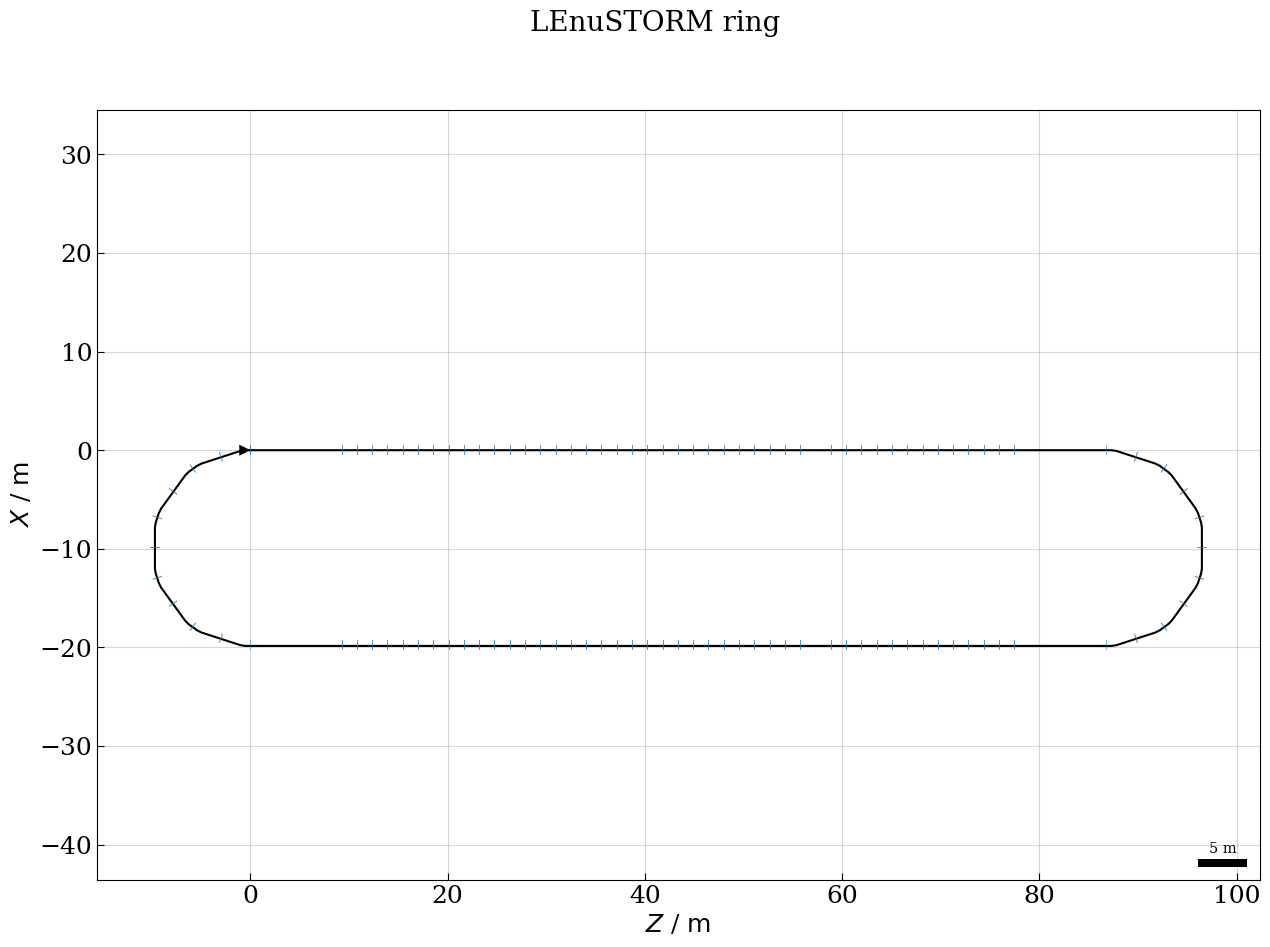

In [207]:
if True:
    import xplt
    plot = xplt.FloorPlot(nustormring.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title('LEnuSTORM ring ')
    plot.ax.set(ylim=(-10, 1))
    
    # plot2 = xplt.KnlPlot(nustormring, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));
    
    

## Load the T2R beam transfer line

In [208]:
# fin = '../src/transfer-line-1050.json'
fin = '../src/20250922-t2r-line.json'
t2rline = xt.Line.from_json(fin)

_t2renv = t2rline.env
_t2renv.new('t2rend', xt.Marker)
t2rline.insert([
    _t2renv.place('t2rend', at=t2rline.get_length())
    ])

t2rline_df = t2rline.to_pandas()
t2rline_df['length'] = t2rline_df['s_end'] - t2rline_df['s_start']
    
t2rline_df['kvalue'] = t2rline_df.apply(lambda x: get_kvalue(x), axis=1)

t2rsrv_df = t2rline.survey().to_pandas()
t2rsrv_df = t2rsrv_df.rename(columns={'name':'name_srv'})
display(t2rsrv_df[t2rsrv_df.element_type != 'Drift'].head(40))

t2rline_df = t2rline_df.join(t2rsrv_df[['name_srv','X','Y','Z','theta','phi','psi','angle','tilt']], how='outer')
assert t2rline_df.isna().any().any(), 'NaN values found in the dataframe' # there should be no NaN if dataframes of same length

t2rline_elements_df = get_flukadf(t2rline_df, verbose=True)

display(t2rline_elements_df.head())

Loading line from dict:   0%|          | 0/32 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/31 [00:00<?, ?it/s]

,X,Y,Z,theta,phi,psi,name_srv,s,length,isthick,drift_length,angle,tilt,element_type
0,0.000000,0.0,0.000000,0.000000,0.0,0.0,mbtl0.0,0.000000,1.500000,True,1.500000,0.428280,0.0,Bend
2,-0.523984,0.0,1.909403,-0.428280,0.0,0.0,mq_t2r.0,2.000000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
4,-1.063883,0.0,3.091989,-0.428280,0.0,0.0,mq_t2r.1,3.300000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
6,-1.603782,0.0,4.274575,-0.428280,0.0,0.0,mq_t2r.2,4.600000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
8,-2.143681,0.0,5.457161,-0.428280,0.0,0.0,mbtl0.1,5.900000,1.500000,True,1.500000,0.428280,0.0,Bend
10,-3.496608,0.0,7.048692,-0.856560,0.0,0.0,mq_t2r.3,8.010218,0.800000,True,0.800000,0.000000,0.0,Quadrupole
12,-4.259922,0.0,7.710426,-0.856560,0.0,0.0,mq_t2r.4,9.020436,0.800000,True,0.800000,0.000000,0.0,Quadrupole
14,-5.023237,0.0,8.372159,-0.856560,0.0,0.0,mq_t2r.5,10.030654,0.800000,True,0.800000,0.000000,0.0,Quadrupole
16,-5.786551,0.0,9.033893,-0.856560,0.0,0.0,mq_t2r.6,11.040872,0.800000,True,0.800000,0.000000,0.0,Quadrupole
18,-6.700985,0.0,9.826634,-0.856560,0.0,0.0,mq_t2r.7,12.251090,0.800000,True,0.800000,0.000000,0.0,Quadrupole


 -- belements: {'mb2', 'mb3', 'mb1', 'mq10', 'mq7', 'mq3', 'mq8', 'mq2', 'mb4', 'mq9', 'mq5', 'mq1', 'mq6', 'mq11', 'mq4'}
 -- models: {'MB150', 'QM80', 'MB138'}


,s,element_type,name,isthick,isreplica,parent_name,iscollective,element,s_start,s_center,...,psi,angle,tilt,length_cm,X_cm,Y_cm,Z_cm,theta_deg,belement,model
0,0.0,Bend,mbtl0.0,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",0.0,0.75,...,0.0,0.42828,0.0,150.0,0.000000,0.0,0.000000,0.000000,mb1,MB150
2,2.0,Quadrupole,mq_t2r.0,True,False,None,False,"Quadrupole(k1=-0.801, k1s=0, length=0.8, num_m...",2.0,2.40,...,0.0,0.00000,0.0,80.0,-52.398374,0.0,190.940341,-24.538648,mq1,QM80
4,3.3,Quadrupole,mq_t2r.1,True,False,None,False,"Quadrupole(k1=1.4, k1s=0, length=0.8, num_mult...",3.3,3.70,...,0.0,0.00000,0.0,80.0,-106.388277,0.0,309.198915,-24.538648,mq2,QM80
6,4.6,Quadrupole,mq_t2r.2,True,False,None,False,"Quadrupole(k1=-0.801, k1s=0, length=0.8, num_m...",4.6,5.00,...,0.0,0.00000,0.0,80.0,-160.378180,0.0,427.457490,-24.538648,mq3,QM80
8,5.9,Bend,mbtl0.1,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",5.9,6.65,...,0.0,0.42828,0.0,150.0,-214.368083,0.0,545.716064,-24.538648,mb2,MB150


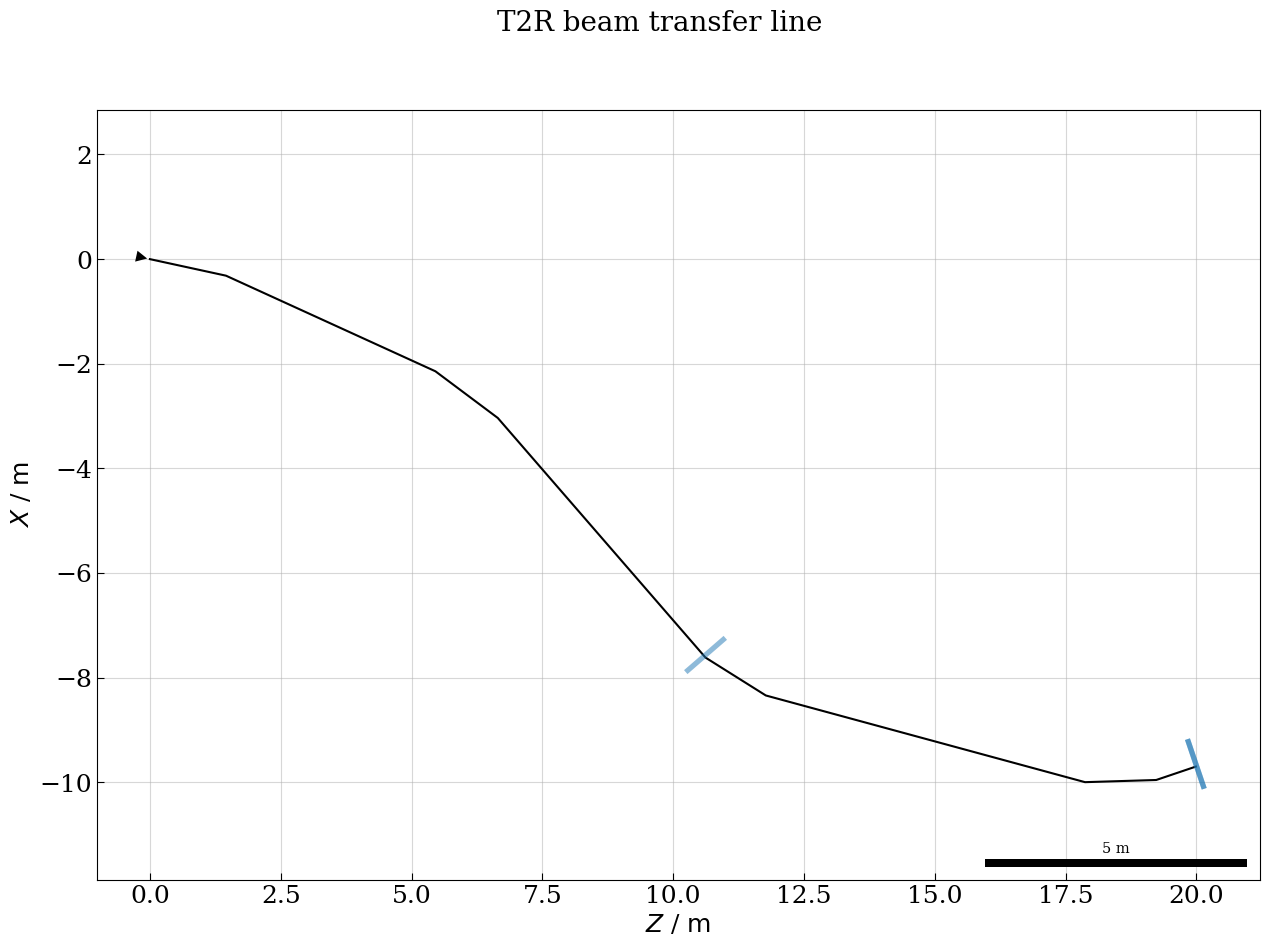

In [209]:
if True :
    import xplt
    plot = xplt.FloorPlot(t2rline.survey(), figsize=(15,10))
    plot.add_scale()
    plot.title('T2R beam transfer line')
    plot.ax.set(ylim=(-10, 1))
    
    _xval = [t2rline_df.iloc[0].Z, t2rline_df.iloc[-1].Z]
 
    # plot2 = xplt.KnlPlot(t2rline, figsize=(7, 3))
    # plot2.ax.set(ylim=(-1, 1));

In [210]:
# --- T2R segments
_segments = [group for _, group in t2rline_elements_df[t2rline_elements_df.element_type.isin(['Bend', 'Quadrupole'])].groupby("theta", sort=False)]
print(len(_segments))
t2r_segments = []
for seg in _segments:
    print(f' --- new segment: angle = {seg.iloc[0].theta:.6f} [rad]')
    print(f' \t elements = {seg.belement.values}')
    _slen = seg.iloc[-1].s_end - seg.iloc[0].s_start 
    print(f'\t  s-length = {_slen:.6f}')

4
 --- new segment: angle = 0.000000 [rad]
 	 elements = ['mb1']
	  s-length = 1.500000
 --- new segment: angle = -0.428280 [rad]
 	 elements = ['mq1' 'mq2' 'mq3' 'mb2']
	  s-length = 5.400000
 --- new segment: angle = -0.856560 [rad]
 	 elements = ['mq4' 'mq5' 'mq6' 'mq7' 'mq8' 'mb3']
	  s-length = 6.831856
 --- new segment: angle = -0.265205 [rad]
 	 elements = ['mq9' 'mq10' 'mq11' 'mb4']
	  s-length = 6.307768


## Build FLUKA Geometry

Model parking area
x = -500 +500     Dx = 10 m
z = -20000 -5000 Dz = 150 m

Injection point to LEnuSTORM ring
x = -10 m from target
z =  15 m from target
angle = to point to a ND module at 250m from the target.

**Note** : for FLUKA the units are converted to cm 

In [211]:
# -- calculate overall angle of LEnuSTORM ring
# Note: 
# - the points are always as {x,z} or {x,y,z} coordinates 
# - units are [m, rad], other units are defined in the name of the variable

t2r_start   = config.t2r_start
t2r_end     = t2r_start + t2rline_df[['X', 'Z']].iloc[-1].to_numpy()
t2r_angle   = np.arcsin(t2rline_df.iloc[-1].X/t2rline_df.iloc[-1].Z)
t2r_length  = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

config.update({'t2r_end'        : t2r_end,
               't2r_angle'      : t2r_angle,
               't2r_angle_deg'  : t2r_angle * 180/np.pi,
               't2r_length'     : t2r_length,
               })

lblnd_point = [0, config.trg_to_lblnd]

injection_point         = np.add(t2r_start, config.t2rstart_to_inj)
nsring_angle, nsring_c  =  bsim.line_from_points(injection_point[::-1], lblnd_point[::-1])
nsring_angle_deg        = nsring_angle*180/np.pi
nsring_width            = nustormring_df.X.max() - nustormring_df.X.min() + 2*config.magnet_width
nsring_length           = nustormring_df.Z.max() - nustormring_df.Z.min() - 2*config.magnet_width

config.update({
    'nsring_inj'        : injection_point,
    'nsring_angle'      : nsring_angle,
    'nsring_angle_deg'  : nsring_angle_deg,
    'nsring_width'      : nsring_width,
    'nsring_lengh'      : nsring_length,
    
})

nsdist_to_dtnl = bsim.distance_point_to_line([nsring_angle, nsring_c], [config.l_decay_tunnel, -config.w_decay_tunnel/2])
config.update({'nsdist_to_dtnl' : nsdist_to_dtnl})

print(f' === Parameters for the T2R line and LEnuSTORM ring ====')
print(f' -  target to ND distance ...................[m] {config.trg_to_lblnd}')
print(f' -  T2R beam transfer line:')
print(f'              start .........................[m] x={t2r_start[0]} z={t2r_start[1]}')
print(f'              end ...........................[m] x={t2r_end[0]} z={t2r_end[1]}')
print(f'              angle .........................{t2r_angle:.5f} [rad], {t2r_angle*180/np.pi:.2f} [deg]')

print(f' -  LEnuSTORM ring:')
print(f'              injection point to target .....[m] x={injection_point[0]} z={injection_point[1]}')
print(f'              angle ......................... {nsring_angle:.5f} [rad] {nsring_angle_deg:.3f} [deg]')
print(f'              tunnel width ..................[m] x={nsring_width:.5f} ')
print(f'              tunnel length .................[m] x={nsring_length:5f} ')

print(f' - Distance to edge of the decay tunnel .....[m] {nsdist_to_dtnl:.5f} ')


 === Parameters for the T2R line and LEnuSTORM ring ====
 -  target to ND distance ...................[m] 320
 -  T2R beam transfer line:
              start .........................[m] x=0 z=2.0
              end ...........................[m] x=-9.698399900672612 z=21.990140928352357
              angle .........................-0.50655 [rad], -29.02 [deg]
 -  LEnuSTORM ring:
              injection point to target .....[m] x=-9.08278251237319 z=25.1539181004073
              angle ......................... 0.03081 [rad] 1.765 [deg]
              tunnel width ..................[m] x=21.44435 
              tunnel length .................[m] x=104.553357 
 - Distance to edge of the decay tunnel .....[m] 1.00886 


In [212]:
# --- Update the T2R and nuSTORM dataframes with the final position and rotation

t2rline_elements_df[['Xp', 'Zp']] = (t2rline_elements_df[['X', 'Z']] + t2r_start)
t2rline_elements_df[['Xp_cm', 'Zp_cm']] = (t2rline_elements_df[['Xp', 'Zp']])*100


# --- Rotation matrix ---
R = np.array([[np.cos(-nsring_angle), -np.sin(-nsring_angle)],
              [np.sin(-nsring_angle),  np.cos(-nsring_angle)]])

rotated = nustormring_elements_df[['X', 'Z']].to_numpy() @ R.T  # matrix multiply
nustormring_elements_df['Xp'] = rotated[:,0] + injection_point[0]
nustormring_elements_df['Zp'] = rotated[:,1] + injection_point[1]
nustormring_elements_df[['Xp_cm', 'Zp_cm']] = (nustormring_elements_df[['Xp', 'Zp']])*100



Text(0.5, 1.0, 'ESSnuSB+ LEnuSTORM Layout')

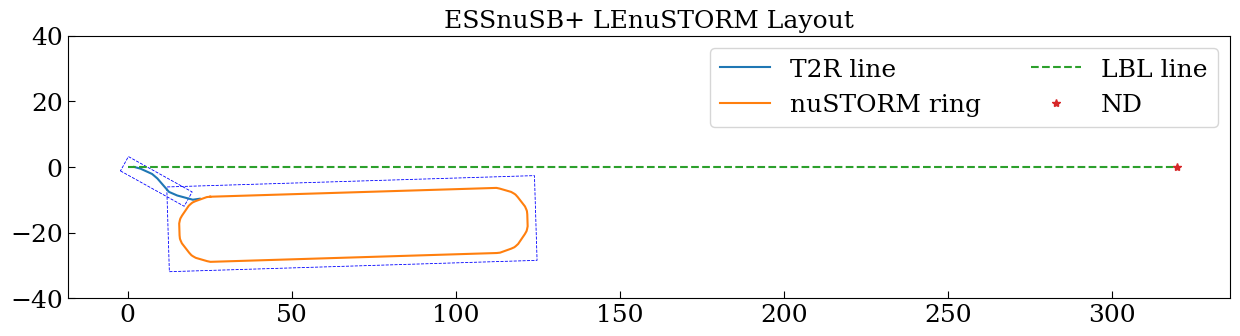

In [ ]:
fig,ax = plt.subplots(figsize=(15,10))

# ax.plot(t2rline_elements_df.Z+t2r_start[1], t2rline_elements_df.X+t2r_start[0], label='T2R line')
ax.plot(t2rline_elements_df.Zp, t2rline_elements_df.Xp, label='T2R line')

_twidth = config.w_tline_tunnel
_bottom_left_corner = (-_twidth/2 * np.cos(t2r_angle), _twidth/2 * np.sin(t2r_angle))
_width = _twidth
_length = np.linalg.norm(t2rline_df.iloc[-1][['X','Z']].to_numpy())

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle =t2r_angle*180/np.pi,
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

# ax.plot(_dfy.Zrot, _dfy.Xrot, label='nuSTORM ring')
ax.plot(nustormring_elements_df.Zp, nustormring_elements_df.Xp, label='nuSTORM ring')

_bottom_left_corner = (nustormring_elements_df.Zp.min()-3, nustormring_elements_df.Xp.min()-3)
_width = nustormring_elements_df.X.max() - nustormring_elements_df.X.min()+2*3
_length = nustormring_elements_df.Z.max() - nustormring_elements_df.Z.min() + 2*3

rect = patches.Rectangle(_bottom_left_corner, _length, _width,
                         angle = nsring_angle*180/np.pi, 
                         facecolor='lightblue',
                         fill=False, edgecolor='blue', linestyle='--', linewidth=0.6)
ax.add_patch(rect)

lblline = list(zip([0,0],lblnd_point))
ax.plot(lblline[1], lblline[0], '--', label='LBL line')
ax.plot(config.trg_to_lblnd, 0, '*', label='ND')
ax.legend(ncols=2)
ax.set_ylim(-40, 40)
ax.set_aspect('equal', adjustable='box')
ax.set_title('ESSnuSB+ LEnuSTORM Layout')



### Create magnet models

In [68]:
if True : 
    k0 = 0.428
    slength = 2.21
    angle = 0.428*slength
    print(f'{angle=} {angle*180/np.pi=}')
    rho = 1/k0
    arc = 2*rho*np.sin(angle/2)
    print(f'{k0=}, {angle=}, {rho=}, {arc=}')
    zlength = rho*np.sin(angle)
    b0 = angle*1000*0.7/299.79/slength
    print(f' {zlength=}, {b0=}')


angle=0.9458799999999999 angle*180/np.pi=54.194931925834304
k0=0.428, angle=0.9458799999999999, rho=2.336448598130841, arc=np.float64(2.128530537793036)
 zlength=np.float64(1.8948880225009936), b0=0.9993662230227826


In [69]:
def create_quad_model(name, length, verbose=False):
    ''' Create the model of the quads'''
    aperture = 20
    width = 3.9*aperture
    height = width
    name = name.lower()
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-width/2} {width/2} 0 {length}
RCC     {name}vac 0.0 0.0 -0.1 0.0 0.0 {length+0.1} {aperture/2}'''

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac '''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}'''

    lattice = f'''
LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''

    if verbose:
        print(f'''--- QUAD model :
              name ......... {name}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperture ..... {aperture}
              ''')


    return bodies, regions, replica, lattice

def create_bend_model(name, slength, k0, verbose=False):
    ''' Create the model of the bends'''
    beam_size = 20
    angle = k0*(slength/100)
    rho = 1/k0*100
    arc = 2*rho*np.sin(angle/2)
    defl = arc*np.sin(angle/2)
    length = rho * np.sin(angle)
    width = 2*(defl + beam_size)*1.2 + 2*30  # here the beam enters the center of the dipole
    height = beam_size + 2*30
    aperx = 2*(defl + beam_size)*1.2
    apery = 1.2 * beam_size
    name = name.lower()
    if verbose:
        print(f'''--- BEND model :
              name ......... {name}
              slength ...... {slength}
              k0 ........... {k0}
              angle ........ {angle}
              rho .......... {rho}
              arc .......... {arc}
              deflection ... {defl}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperx ........ {aperx}
              apery ........ {apery}
              ''')
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-height/2-0.1} {height/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-height/2} {height/2} 0 {length}
RPP     {name}vac {-aperx/2} {aperx/2} {-apery/2} {apery/2} -0.1 {length+0.1}''' 

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac'''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}''' 

    lattice = f'''
LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''


    return bodies, regions, replica, lattice

In [74]:
_aux = t2rline_elements_df.dropna(subset='model')
models_dict = _aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict()

_aux = nustormring_elements_df.dropna(subset='model')
models_dict.update(_aux.set_index("model").apply(lambda r: 
                {'length' : round(r["length"]*100, 2), 
                 'type'   : r["element_type"], 
                 'kvalue' : r["kvalue"]}, axis=1).to_dict())

models_dict

{'MB150': {'length': 150.0, 'type': 'Bend', 'kvalue': 0.28552013202450904},
 'QM80': {'length': 80.0, 'type': 'Quadrupole', 'kvalue': 0.3678530140270088},
 'MB138': {'length': 138.08, 'type': 'Bend', 'kvalue': -0.4282801980367636},
 'QM12': {'length': 12.5, 'type': 'Quadrupole', 'kvalue': 2.1941773633721193},
 'QM25': {'length': 25.0, 'type': 'Quadrupole', 'kvalue': -2.089355412989841},
 'MB50': {'length': 50.0, 'type': 'Bend', 'kvalue': 0.6283185307179586}}

In [75]:
mparking = np.array(config.mparking_start)*100
mbodies_cards = ''
mregions_cards = ''
mrotdefi_cards = ''
mlattice_cards = ''

for mid, mparams in models_dict.items():
    print(f'{mid=}, {mparams=}')
    length, mtype, kvalue = mparams.values()
    
    if mtype == 'Quadrupole':
        bodies, regions, replica, lattice = create_quad_model(mid, length, True)
    elif mtype == 'Bend' :
        bodies, regions, replica, lattice = create_bend_model(mid, length, kvalue, True)
    else:
        continue
    _rotdefi = ''
    bodies = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + bodies + '\n$end_translat'
    models_dict[mid]['bodies'] = bodies
    mbodies_cards += bodies + '\n'

    replica = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + replica + '\n$end_translat'
    models_dict[mid]['replicas'] = replica

    mregions_cards += regions

    _thismodel = {'name': str(mid),
                  'bodies' : bodies,
                  'regions' : regions,
                  'replicas' : replica,
                  'lattice' : lattice,
                  'parking' : mparking.copy(),
                  }
    models_dict[mid].update(_thismodel) 
    
    mparking[2] += -300
print(f' --- mparking_end = {mparking}')
config.update({'mparking_end': list(mparking/100)})
print(f' ---- Model Bodies :')
print(mbodies_cards)
print(f' ---- Model Regions')
print(mregions_cards)

print(f' --- Magnet Models dict : ')
pprint.pprint(models_dict) 

mid='MB150', mparams={'length': 150.0, 'type': 'Bend', 'kvalue': 0.28552013202450904}
--- BEND model :
              name ......... mb150
              slength ...... 150.0
              k0 ........... 0.28552013202450904
              angle ........ 0.42828019803676354
              rho .......... 350.238
              arc .......... 148.8562260457135
              deflection ... 31.63302673121214
              length ....... 145.45627402210937
              width ........ 183.91926415490911
              height ....... 80
              aperx ........ 123.91926415490913
              apery ........ 24.0
              
mid='QM80', mparams={'length': 80.0, 'type': 'Quadrupole', 'kvalue': 0.3678530140270088}
--- QUAD model :
              name ......... qm80
              length ....... 80.0
              width ........ 78.0
              height ....... 78.0
              aperture ..... 20
              
mid='MB138', mparams={'length': 138.08, 'type': 'Bend', 'kvalue': -0.428280198036763

In [76]:
with open(f'lenustorm_models_bodies.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM magnet models bodies  ----\n*\n''')
    f.write(mbodies_cards)
    
with open(f'lenustorm_models_regions.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM magnet models regions  ----\n*''')
    f.write(mregions_cards)

### Create T2R line elements

In [95]:

t2r_replica_cards = ''
t2r_regions_cards = ' '
t2r_rotdefi_cards = ''
t2r_lattice_cards = ''
t2r_lattice_regions = ''

_x0cm, _z0cm = np.array(config.t2r_start)*100

for el in t2rline_elements_df.itertuples():
    print(el.name, el.model)
    if el.model not in models_dict.keys():
        print (f' ---- {el.name=} cannot find model')
        continue
        
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.name.lower()))
    # print(model, parking, replica)
    
    xc = _x0cm + el.X_cm
    yc = el.Y_cm
    zc = _z0cm + el.Z_cm
    angle = el.theta_deg

    _thisrotdefi = f'''
*! - ROTDEFI for element {el.name} at s={el.s_center}
ROT-DEFI  , 0, , ,{-xc}, {-yc}, {-zc}, t2rtr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , tltr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, tltr{el.Index} '''

    _thisreplica = f'''
$start_transform -tltr{el.Index}
{replica}
$end_transform'''

    t2r_lattice_regions += f' -{el.name.lower()}'
    
    _thisregion = f'''
{el.name.upper()} 5
    +{el.name.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'tltr{el.Index}').replace('rpregion',el.name.upper())
       
    print(_thisregion)
    print(_thisrotdefi)
    print(_thisreplica) 
    print(_thislattice)
       
    t2r_replica_cards += _thisreplica
    t2r_rotdefi_cards += _thisrotdefi
    t2r_regions_cards += _thisregion
    t2r_lattice_cards += _thislattice

mbtl0.0 MB150

MBTL0.0 5
    +mbtl0.0

*! - ROTDEFI for element mbtl0.0 at s=0.75
ROT-DEFI  , 0, , ,-0.0, -0.0, -200.0, t2rtr0
ROT-DEFI  , 200, , 0, , , , tltr0 
ROT-DEFI  , 300, , 0, 0, 0, -10100, tltr0 

$start_transform -tltr0
$start_translat 0 0 -10100
RPP     mbtl0.0 -92.05963207745455 92.05963207745455 -92.05963207745455 92.05963207745455 -0.1 145.55627402210936
$end_translat
$end_transform

LATTICE, MBTL0.0, , , MB150Env, , ,tltr0
mq_t2r.0 QM80

MQ_T2R.0 5
    +mq_t2r.0

*! - ROTDEFI for element mq_t2r.0 at s=2.4
ROT-DEFI  , 0, , ,52.398374012505066, -0.0, -390.94034103779416, t2rtr2
ROT-DEFI  , 200, , -24.5386, , , , tltr2 
ROT-DEFI  , 300, , 0, 0, 0, -10400, tltr2 

$start_transform -tltr2
$start_translat 0 0 -10400
RPP     mq_t2r.0 -39.1 39.1 -39.1 39.1 -0.1 80.1
$end_translat
$end_transform

LATTICE, MQ_T2R.0, , , QM80Env, , ,tltr2
mq_t2r.1 QM80

MQ_T2R.1 5
    +mq_t2r.1

*! - ROTDEFI for element mq_t2r.1 at s=3.7
ROT-DEFI  , 0, , ,106.38827694386667, -0.0, -509.198915278574

In [96]:
with open(f't2rline_elements_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element ROT-DEFI ----\n*''')
    f.write(t2r_rotdefi_cards)

with open(f't2rline_elements_replicas.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element replicas ----\n*''')
    f.write(t2r_replica_cards)
    
with open(f't2rline_elements_regions.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element regions ----\n*''')
    f.write(t2r_regions_cards)
    
with open(f't2rline_elements_lattice.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element lattice ----\n*''')
    f.write(t2r_lattice_cards)

### Create LEnuSTORM beam elements

In [126]:
# --- rename the bends as MBxx without dot

nustormring_elements_df['belement'] = nustormring_elements_df['belement'].apply(lambda x: x.replace('B.','MB')).values

In [127]:
# -- sanity check if any name >8 characters that FLUKA needs
_dfy = nustormring_elements_df.copy()
_dfy['belement_nlen'] = _dfy['belement'].astype(str).apply(len)
mask = (
    (_dfy["element_type"] != "Drift") &
    (
        (_dfy["belement_nlen"] > 8) |
        (_dfy["belement"].astype(str).str.contains(r"\."))
    )
)
_dfy[mask][['element_type', 'name','belement', 'model']]

,element_type,name,belement,model


In [134]:
config

{'trg_to_lblnd': 320,
 'ss_to_lemmond': 50,
 'l_decay_tunnel': 60,
 'w_decay_tunnel': 14,
 'r_decay_pipe': 2.5,
 'h_decay_tunnel': 13,
 'w_ring_tunnel': 2,
 'h_ring_tunnel': 4,
 'ring_walls': 2,
 'w_tline_tunnel': 5,
 'h_tline_tunnel': 4,
 't_tline_tunnel': 2,
 'mparking_start': [0, 0, -101],
 'mparking_radius': 10,
 't2r_start': [0, 2.0],
 't2rend_to_inj': [-2, 6.0],
 't2rstart_to_inj': [-9.08278251237319, 23.1539181004073],
 'beam_size': 0.1,
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'magnet_width': 0.8,
 'd1_aperture_margin': 1.2,
 't2r': {'l_bend_end': 0.35,
  'l_bend_woke': 0.5,
  'l_quad_end': 0.2,
  'l_quad_w': 0.6,
  'l_quad_h': 0.6,
  'l_qfl_end': 0.2,
  'l_qfl_w': 0.9,
  'l_qfl_h': 0.9,
  'l_vac': 0.1},
 't2r_end': array([-9.6983999 , 21.99014093]),
 't2r_angle': np.float64(-0.5065451704646352),
 't2r_angle_deg': np.float64(-29.022900400358438),
 't2r_length': np.float64(22.21856644720254),
 'nsring_inj': array([-9.08278251, 25.1539181 ]),
 'nsring_angle': np.float64(0.030

In [128]:
if False:
    
    # --- the half length elements
    _cols2use = ['s_fr','element_type','name_fr','name_srv','el_name','model_id', 'model_name']
    lenustorm_df[lenustorm_df['Consecutive_Count'] != 1][frcols2use]
    
    # --- the full length or first elements

    lenustorm_magnetic_elements = lenustorm_df[(lenustorm_df.Consecutive_Count == 1) & (lenustorm_df.element_type != 'Drift')]
    lenustorm_magnetic_elements[frcols2use].tail()

In [215]:
config

{'trg_to_lblnd': 320,
 'ss_to_lemmond': 50,
 'l_decay_tunnel': 60,
 'w_decay_tunnel': 14,
 'r_decay_pipe': 2.5,
 'h_decay_tunnel': 13,
 'w_ring_tunnel': 2,
 'h_ring_tunnel': 4,
 'ring_walls': 2,
 'w_tline_tunnel': 5,
 'h_tline_tunnel': 4,
 't_tline_tunnel': 2,
 'mparking_start': [0, 0, -101],
 'mparking_radius': 10,
 't2r_start': [0, 2.0],
 't2rend_to_inj': [-2, 6.0],
 't2rstart_to_inj': [-9.08278251237319, 23.1539181004073],
 'beam_size': 0.1,
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'magnet_width': 0.8,
 'd1_aperture_margin': 1.2,
 't2r': {'l_bend_end': 0.35,
  'l_bend_woke': 0.5,
  'l_quad_end': 0.2,
  'l_quad_w': 0.6,
  'l_quad_h': 0.6,
  'l_qfl_end': 0.2,
  'l_qfl_w': 0.9,
  'l_qfl_h': 0.9,
  'l_vac': 0.1},
 't2r_end': array([-9.6983999 , 21.99014093]),
 't2r_angle': np.float64(-0.5065451704646352),
 't2r_angle_deg': np.float64(-29.022900400358438),
 't2r_length': np.float64(22.21856644720254),
 'nsring_inj': array([-9.08278251, 25.1539181 ]),
 'nsring_angle': np.float64(0.030

In [216]:
nustormring_elements_df.columns

Index(['s', 'element_type', 'name', 'isthick', 'isreplica', 'parent_name',
       'iscollective', 'element', 's_start', 's_center', 's_end', 'name_srv',
       'X', 'Y', 'Z', 'theta', 'phi', 'psi', 'angle', 'tilt', 'length',
       'kvalue', 'length_cm', 'X_cm', 'Y_cm', 'Z_cm', 'theta_deg', 'belement',
       'model', 'Xp', 'Zp', 'Xp_cm', 'Zp_cm'],
      dtype='object')

In [218]:
ns_replica_cards = ''
ns_regions_cards = ' '
ns_rotdefi_cards = ''
ns_lattice_cards = ''

ns_lattice_regions = ''


icount = 0
for el in nustormring_elements_df[nustormring_elements_df.element_type != 'Marker'].itertuples():
    if el.model not in models_dict.keys():
        print (f' --- {el.name=} : cannot find a model')
        continue
    model = models_dict[el.model]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.belement.lower()))
    print(f'{el.belement=}, {model=}, {parking=}, {replica=}')
    
    angle = -config.nsring_angle_deg - el.theta_deg + el.angle*180/np.pi/2
    if angle > 180 :
        # print(f' --- frtr{el.Index} ; element:{el.el_name} - {el.name_fr} {angle=:.5f} --> {360-angle:.5f} ({lenustorm_angle_deg=:.5f} {el.theta_deg:.5f} {el.angle*180/np.pi/2=:.5f})')
        angle = 360 - angle
    else:
        angle = -angle
        
    _thisrotdefi = f'''
*! - ROTDEFI for element {el.belement} at s={el.s_center}
ROT-DEFI  , 0, , ,{-el.Xp_cm:.5f}, ,{-el.Zp_cm:.5f}, nstr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , nstr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, frtr{el.Index} '''

    _thisreplica = f'''
$start_transform -nstr{el.Index}
{replica}
$end_transform'''
    
    _thisregion = f'''
{el.belement.upper()} 5
    +{el.belement.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'frtr{el.Index}').replace('rpregion',el.belement.upper())
    
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    ns_replica_cards += _thisreplica
    ns_rotdefi_cards += _thisrotdefi
    ns_regions_cards += _thisregion
    ns_lattice_cards += _thislattice
    
    ns_lattice_regions += f' -{el.belement.lower()}'
    if icount % 10 == 0 :
        ns_lattice_regions += '\n'

el.belement='QF1', model={'length': 12.5, 'type': 'Quadrupole', 'kvalue': 2.1941773633721193, 'bodies': '$start_translat 0 0 -11000\nRPP     qm12vol -39.1 39.1 -39.1 39.1 -0.1 12.6\nRPP     qm12fe -39.0 39.0 -39.0 39.0 0 12.5\nRCC     qm12vac 0.0 0.0 -0.1 0.0 0.0 12.6 10.0\n$end_translat', 'replicas': '$start_translat 0 0 -11000\nRPP     replica -39.1 39.1 -39.1 39.1 -0.1 12.6\n$end_translat', 'name': 'QM12', 'regions': '\nQM12Env 5\n    +qm12vol -qm12fe -qm12vac\nQM12Fe 5\n    +qm12fe -qm12vac\nQM12Vac 5\n    +qm12vac ', 'lattice': '\nLATTICE, rpregion, , , QM12Env, , ,transform', 'parking': array([     0,      0, -11000])}, parking=array([     0,      0, -11000]), replica='$start_translat 0 0 -11000\nRPP     qf1 -39.1 39.1 -39.1 39.1 -0.1 12.6\n$end_translat'
el.belement='QD1', model={'length': 25.0, 'type': 'Quadrupole', 'kvalue': -2.089355412989841, 'bodies': '$start_translat 0 0 -11300\nRPP     qm25vol -39.1 39.1 -39.1 39.1 -0.1 25.1\nRPP     qm25fe -39.0 39.0 -39.0 39.0 0 25.0\nR

In [220]:
# print(rotdefi_cards)
# print(regions_cards)
# print(replica_cards)

with open(f'lenustorm_elements_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element ROT-DEFI ----\n*''')
    f.write(ns_rotdefi_cards)

with open(f'lenustorm_elements_replicas.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element replicas ----\n*''')
    f.write(ns_replica_cards)
    
with open(f'lenustorm_elements_regions.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element regions ----\n*''')
    f.write(ns_regions_cards)
    
with open(f'lenustorm_elements_lattice.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element lattice ----\n*''')
    f.write(ns_lattice_cards)

## Create global volumes 

- target cavern
- tunnels for T2R and nuSTORM ring

In [221]:
def create_parking(pstart, pend, pradius, wthick=200):
    plength = abs(pend[2]) - abs(pstart[2]) + wthick
    bodies = f'''
RCC parko {pend[0]}, {pend[1]}, {pend[2] + math.copysign(wthick, pend[2])}, 0, 0, {plength + 2*wthick}, {pradius + wthick}
RCC parki {pend[0]}, {pend[1]}, {pend[2]}, 0, 0, {plength}, {pradius}
'''
    return bodies

In [ ]:
if False : 
    bsim_parameters
    print(lenustorm_df.Z.min(), tt_inj_point[1], bsim_parameters["w_ring_tunnel"])
    print(tt_inj_point[1]+lenustorm_df.Z.min()-bsim_parameters["w_ring_tunnel"]/2)

    print(tt_length)


    print(bsim_parameters["w_ring_tunnel"]*100, tt_inj_point[1]*100,  lenustorm_df.Z.min()*100)
    print(-bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100)
    bsim_parameters
    pc_primary = np.sqrt(2.5*(2.5+2*0.9382))
    primary_d1_angle = tt_bend_angle*0.7/pc_primary
    print(f' --- primary beam momentum ... {pc_primary:.5g} [GeV]')
    print(f' --- angle in Bend1 .......... {primary_d1_angle:.5g} [deg]')
    bsim_parameters
    bsim_parameters


In [ ]:
models_and_tunnels_bodies = ''
models_and_tunnels_rotdefi = ''
models_and_tunnels_regions = ''

# --- Parking

_pbodies = create_parking(np.array(config.mparking_start)*100,
                          np.array(config.mparking_end)*100, 
                          config.mparking_radius*100)

models_and_tunnels_bodies += _pbodies

_mvols = '-' + ' -'.join([ v['name']+'vol' for k,v in models_dict.items()])

models_and_tunnels_regions += f'''
PARKBB       5 +parko -parki
PARK         5 +parki {_mvols}
  '''

# --- T2R tunnel

models_and_tunnels_rotdefi += f'''
*! - ROTDEFI for T2R line punchthrough tunnel
ROT-DEFI  , 200, , {t2r_angle*180/np.pi}, , , , t2rtnl 
ROT-DEFI  , 0, , ,{t2r_start[0]*100}, 0.0 ,{t2r_start[1]*100}, t2rtnl
'''

_ww = config.w_tline_tunnel*100
_tt = config.t_tline_tunnel*100
_hh = config.h_tline_tunnel*100
_ll = config.l_tline_tunnel*100

models_and_tunnels_bodies += f'''

$start_transform t2rtnl
RPP   t2rtnlo  {-(_ww/2+_tt)} {_ww/2+_tt} {-(_hh/2 + _tt)} {_hh/2 + _tt} {-t2r_start[1]*100} {_ll}
RPP   t2rtnli  {-_ww/2} {_ww/2} {-_hh/2} {_hh/2} {t2r_start[1]*100} {_ll}
$end_transform
'''

models_and_tunnels_regions += f'''
PARKBB       5 +t2rtnlo -tr2tnli
PARK         5 +parki {_mvols}
  '''


# --- Target cavern 


_wtmp = bsim_parameters['w_tline_tunnel']*100
_htmp = bsim_parameters['h_tline_tunnel']*100

_width  = bsim_parameters['w_tline_tunnel']*100
_height = bsim_parameters['h_tline_tunnel']*100



# --- Ring tunnel

_ring_w = ((lenustorm_df.X.max()-lenustorm_df.X.min())+bsim_parameters['w_ring_tunnel']*2)*100
_ring_upstream = 5*100 # upstream margin to match the TL entrance
_ring_len = (lenustorm_df.Z.max()-lenustorm_df.Z.min()+bsim_parameters['w_ring_tunnel']*2)*100
_ring_height = bsim_parameters["h_ring_tunnel"]*100
_ring_zmin = -bsim_parameters["w_ring_tunnel"]*100
_ring_walls = bsim_parameters['ring_walls']*100

models_and_tunnels_bodies += f'''

$start_transform rgtnl
RPP rgtnlo {-_ring_w/2-_ring_walls} {_ring_w/2+_ring_walls} {-_ring_height/2-_ring_walls} {_ring_height/2+_ring_walls} {_ring_zmin-_ring_walls-_ring_upstream} {_ring_len+_ring_upstream+_ring_walls}
RPP rgtnli {-_ring_w/2} {_ring_w/2} {-_ring_height/2} {_ring_height/2} {_ring_zmin-_ring_upstream} {_ring_len+_ring_upstream}
$end_transform
'''

_radius = bsim_parameters['r_decay_pipe']*100
_zmin = tt_d1_pivot[1]*100 + 600
_xmin = bsim_parameters['beam_size']*100*1.2
_xmax = _zmin * primary_d1_angle + _xmin


models_and_tunnels_bodies += f'''

RPP dumpo {-_radius+10} {_radius-10} {-_radius+10} {_radius-10} {_zmin} {_zmin + 600}
RPP dumpc {-_xmax} {_xmin} {-_xmin} {_xmin} {_zmin} {_zmin+100}
! RCC dumpc 0 0 {_zmin} 0 0 100 20
'''

# --- Parking and tunnels ROT-DEFI

_xcenter = (-(lenustorm_df.X.max()-lenustorm_df.X.min())/2 - bsim_parameters['w_tline_tunnel']/2 + tt_inj_point[0])*100
_zcenter = -bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100

models_and_tunnels_rotdefi += f'''

*! - ROTDEFI for LEnuSTORM tunnel
ROT-DEFI  , 0, , ,{_xcenter}, 0.0 ,{_zcenter}, rgtnl
ROT-DEFI  , 200, , -{bsim_parameters["ring_angle_deg"]}, , , , rgtnl 
'''

# --- Parking and tunnels regions

_mvols = '-' + ' -'.join([ v['name']+'vol' for k,v in models_dict.items()])
models_and_tunnels_regions += f'''

PARKBB       5 +parko -parki
PARK         5 +parki {_mvols}
TCC_CAV      5 (+tcc -thbox -tltun -{tlattice_regions.strip().split("-")[1]})
               | +tdec -dumpo {tlattice_regions}
               | +tltun  -dumpo -dumpc {tlattice_regions} -rgtnli
               | +rgtnli {nslattice_regions}
BDUMP        5 +dumpo -dumpc
BDUMPC       5 +dumpc
! TNRING 5
! +rgtnlo -rgtnli
'''

print(models_and_tunnels_bodies)
print(models_and_tunnels_rotdefi)
print(models_and_tunnels_regions)

with open(f'models_and_tunnels_bodies.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels bodies ----\n*''')
    f.write(models_and_tunnels_bodies)

with open(f'models_and_tunnels_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels rotdefi ----\n*''')
    f.write(models_and_tunnels_rotdefi)
    
with open(f'models_and_tunnels_regions.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels regions ----\n*''')
    f.write(models_and_tunnels_regions)

if 0 :
  tt = f'''
* Model Parking
RCC parko     
RPP parko      -1050 1050 -1050 1050 -20050 -9000
RPP parki      -1000 1000 -1000 1000 -20000 -9050


$start_transform tltnl
RPP   tltun  -100 {_wtmp/2} {-_htmp/2} {_htmp/2} -100 {tt_length*100}
$end_transform

*! - ROTDEFI for tline punchthrough tunnel
ROT-DEFI  , 0, , ,{tt_d1_pivot[0]}, 0.0 ,{tt_d1_pivot[1]}, tltnl
ROT-DEFI  , 200, , -{tt_bend_angle_deg}, , , , tltnl 

*! - REGION

TTMBEnv 5
    +tltun {tlattice_regions}
  '''
  print(tl_fluka)

  _ring_w = ((lenustorm_df.X.max()-lenustorm_df.X.min())+bsim_parameters['w_ring_tunnel']*2)*100
  _ring_len = (lenustorm_df.Z.max()-lenustorm_df.Z.min()+bsim_parameters['w_ring_tunnel'])*100
  _ring_height = bsim_parameters["h_ring_tunnel"]*100
  _ring_zmin = -bsim_parameters["w_ring_tunnel"]*100

  _xcenter = (-(lenustorm_df.X.max()-lenustorm_df.X.min())/2 - bsim_parameters['w_tline_tunnel']/2 + tt_inj_point[0])*100
  _zcenter = bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100

  ring_fluka = f'''
  $start_transform rgtnl
  RPP rgtnlo {-_ring_w/2-100} {_ring_w/2+100} {-_ring_height/2-100} {_ring_height/2+100} {_ring_zmin-100} {_ring_len+100}
  RPP rgtnli {-_ring_w/2} {_ring_w/2} {-_ring_height/2} {_ring_height/2} {_ring_zmin} {_ring_len}
  $end_transform

  *! - ROTDEFI for LEnuSTORM tunnel
  ROT-DEFI  , 0, , ,{_xcenter}, 0.0 ,{_zcenter}, rgtnl
  ROT-DEFI  , 200, , -{bsim_parameters["ring_angle_deg"]}, , , , rgtnl 

  TNRING 5
  +rgtnlo -rgtnli

  NSRING 5
    +rgtnli {nslattice_regions}
  '''

## End of code here

In [ ]:
######################
# Obsolete code below
######################

In [ ]:
def plot_trline(df, params):
        
    fig, ax = plt.subplots(figsize=(15,10))

    for el in df.itertuples():
        _name = el.name_tl
        _type = el.element_type
        if _type == 'Bend':
            _length = df.drift_length
            _length_tot = _length + 2*params['l_bend_end']
            _width = df.d1dipole['width']
            _edgecolor = 'blue'
            _facecolor = 'lightblue'
        elif _type == 'Quadrupole' :
            if _name in ['QFL1', 'QFL2']: 
                _length = df.l_qfl
                _length_tot = df.l_qfl_tot
                _width = df.l_qfl_w
                _edgecolor = 'magenta'
                _facecolor = 'yellow'
            else:
                _length = df.l_quad
                _length_tot = df.l_quad_tot
                _width = df.l_quad_w
                _edgecolor = 'orange'
                _facecolor = 'green'
        elif _type == 'Marker':
            if _name == 'TARGET':
                _length = 0.78
                _length_tot = _length
                _width = 0.02
                _edgecolor = 'black'
                _facecolor = 'grey'
            else:
                _length = 0.10
                _length_tot = _length
                _width = 0.10
                _edgecolor = 'black'
                _facecolor = 'grey'
        
        print(f" -- {_name} : xy ={el.coord[1]:.3f}, {el.coord[0]}  {el.angle}")
        _center = (el.coord[1], el.coord[0])

        bottom_left = bsim.compute_corner_from_center(_center, _length_tot, _width, el.angle)
        # print(f'\t --- {bottom_left=}')
        ax.add_patch(
            patches.Rectangle(
                xy=bottom_left, width=_length_tot, height=_width, angle=el.angle*180/np.pi,
                edgecolor='lightgrey', facecolor='brown', linewidth=1, linestyle='--'
            )
        )
        bottom_left = bsim.compute_corner_from_center(_center, _length, _width, el.angle)
        # print(f'\t --- {bottom_left=}')
        ax.add_patch(
            patches.Rectangle(
                xy=bottom_left, width=_length, height=_width, angle=el.angle*180/np.pi,
                edgecolor=_edgecolor, facecolor=_facecolor, linewidth=1
            )
        )
        
        ax.plot(*_center, "ro")  # Center marked as a red dot

    pxx, pzz = df.get_points()
    
    pxx.insert(len(pxx)-1, pxx[len(pxx)-2])
    pzz.insert(len(pzz)-1, 0.5*(pzz[-2]+pzz[-1]))
    ax.plot(pzz[:-1], pxx[:-1], '*-', linewidth=0.7, color='green')
    ax.plot(pzz[-2:], pxx[-2:], '*--', linewidth=0.7, color='olive')

    # ax.set_xlim(0, 18)
    # ax.set_ylim(0, 5)
    ax.set_aspect('equal')

    ax.set_title(df.__getattribute__('method'))
    # Show the plot
    ax.grid(which='major', color='k', linestyle='-', alpha=0.5)
    ax.grid(which='minor', color='r', linestyle='--', alpha=0.2)
    # ax.grid('minor', color='g', linestyle='--')
    ax.minorticks_on()
    plt.show()
    return fig

def plot_layout(tlpoints, ringdf, layout_params):

    fig, ax = plt.subplots(figsize=(20, 10))

    # --- plot infrastructure
    
    x_width = layout_params['w_decay_tunnel']/2*100
    r_decay = layout_params['r_decay_pipe']*100
    z_length = layout_params['l_decay_tunnel']*100
    z_dump = (z_length - 1000)
    
    
    xtunnel = [0, -x_width, -x_width, x_width, x_width, 0]
    rdecay = [0, -r_decay, -r_decay, r_decay, r_decay, 0]
    ztunnel = [0, 0, z_length, z_length, 0, 0]
    zpipe = [0, 0, z_dump, z_dump, 0, 0]

    # plt.plot(ztunnel, xtunnel, 'o-', color='black')
    ax.fill(ztunnel, xtunnel, color='brown')
    ax.fill(zpipe, rdecay, color='cyan')
    ax.plot(layout_params['trg_to_lblnd']*100, 0, 'X', ms=15, color='red', label='LBLND')

    to_lblnd = (layout_params['trg_to_lblnd']+20)*100
    ax.arrow(0, 0, to_lblnd, 0, shape='full', linewidth=2, linestyle='--', 
             length_includes_head=True, head_width=0.5, head_length=8, color='blue', label=None)
    
    xx1 = [float(item[0]) for item in tlpoints]
    zz1 = [float(item[1]) for item in tlpoints]
    ax.plot(np.array(zz1)*100, np.array(xx1)*100, '*-', color='red', label='T2R')
    
    _inj_point = tlpoints[-1]
    _angle = config['ring_angle']
    
    ring_coord_transform = ttline.create_transform(_inj_point[1]*100, _inj_point[0]*100, _angle)
    print(ring_coord_transform)

    ring_2d = ringdf[['Z_cm','X_cm']].to_numpy()
    transformed = ttline.apply_transform(ring_coord_transform, np.array(ring_2d).T)
    ringdf['Z_wc'] = transformed[0]
    ringdf['X_wc'] = transformed[1]

    ring_tunnel_x = np.array([2, 2, ringdf.X.min()-2, ringdf.X.min()-2, 2])*100
    ring_tunnel_z = np.array([ringdf.Z.min()-2, ringdf.Z.max()+2, ringdf.Z.max()+2, ringdf.Z.min()-2, ringdf.Z.min()-2])*100
    ring_tunnel_transformed = ttline.apply_transform(ring_coord_transform, np.array([ring_tunnel_z, ring_tunnel_x]))
    print(ring_tunnel_transformed[0], ring_tunnel_transformed[1])
    # ax.plot(ring_tunnel_transformed[0], ring_tunnel_transformed[1], '*-', color='magenta', label=None)
    ax.fill(ring_tunnel_transformed[0], ring_tunnel_transformed[1], color='moccasin', label=None)

    # ringdf.plot('Z_cm','X_cm', ax=ax)
    # ax.plot(ringdf.iloc[0].Z_cm, ringdf.iloc[0].X_cm, '*', color='red')

    ringdf.plot('Z_wc', 'X_wc', ax=ax, label='LEnuSTORM')
    ax.plot(ringdf.iloc[0].Z_wc, ringdf.iloc[0].X_wc, '*', color='green', label=None)
    
    _endss = ringdf[ringdf.theta == 0].iloc[-1]
    print('-- end of SS:',_endss.Z_wc, _endss.X_wc, layout_params['trg_to_lblnd']*100)
    ax.plot([_endss.Z_wc, layout_params['trg_to_lblnd']*100], [_endss.X_wc, 0], linestyle='--', lw=1, color='green', label=None)
    
    # --- place LEMOND detector
    def place_lemond(ax, ay, bx, by, l):
        ''' return point coordinates at distance l from line (AB)'''
        dx = bx - ax
        dy = by - ay
        ab_length = np.sqrt(dx**2 + dy**2)
        if ab_length == 0:
            raise ValueError("points A and B cannot be the same!")
        udx = dx/ab_length
        udy = dy/ab_length
        cx = ax + l * udx
        cy = ay + l * udy
        return cx, cy
    
    lemond_z, lemond_x = place_lemond(_endss.Z_wc, _endss.X_wc, layout_params['trg_to_lblnd']*100, 0, layout_params['ss_to_lemond']*100)
    print(' --- LEMOND : ', lemond_z, lemond_x)
    ax.plot(lemond_z, lemond_x, 'X', color='brown', ms=15, label='LEMOND')

    ax.fill(bsim_parameters['ring_tunnel_out_coord'][0], bsim_parameters['ring_tunnel_out_coord'][1], '-', color='brown')
    ax.fill(bsim_parameters['ring_tunnel_in_coord'][0], bsim_parameters['ring_tunnel_in_coord'][1], '-', color='orange')

    ax.set_title('ESSnuSB+ : Pion Transfer Line and LEnuSTORM ring layout')
    # plt.title(f'LEnuSTORM ring ($z_{{inj}}$ = {lenustorm_inj_z} [cm], $x_{{inj}}$ = {lenustorm_inj_x} [cm])')
    # ax.plot(transformed[0], transformed[1])
    # ax.plot(transformed[0][0], transformed[1][0], '+', color='green')
    ax.axis('equal')
    ax.grid(which='major', color='r', linestyle='-', alpha=0.5)
    ax.grid(which='minor', color='r', linestyle='--', alpha=0.2)
    ax.minorticks_on()
    ax.legend()
    
    return fig
